
# Dynamic Programming: Recursion → Memoization → Tabulation

This notebook follows the learning progression used in the Dynamic Programming course:

## Part 1 — Memoization
For each problem:

1. Understand the problem
2. Visualize the recursive decision tree / graph
3. Write the brute-force recursive solution
4. Analyze why it is slow
5. Identify repeated subproblems
6. Memoize those repeated states
7. Compare performance

Problems:
- Fibonacci
- Grid Traveler
- `canSum`

## Part 2 — Tabulation
Only after understanding the recursive + memoized versions, we change our way of thinking:

1. Define the table
2. Determine its size
3. Choose the default value
4. Seed the trivial/base case
5. Iterate through the table
6. Propagate each state forward
7. Return the target state

The main goal is to understand the **recipes** rather than memorize individual solutions.



# Setup


In [1]:

from time import perf_counter
import pandas as pd
import matplotlib.pyplot as plt


def benchmark(func, *args, repeats=1):
    start = perf_counter()

    result = None
    for _ in range(repeats):
        result = func(*args)

    end = perf_counter()

    return result, (end - start) / repeats


def format_time(seconds):
    if seconds >= 1:
        return f"{seconds:.4f} s"
    elif seconds >= 1e-3:
        return f"{seconds * 1e3:.4f} ms"
    elif seconds >= 1e-6:
        return f"{seconds * 1e6:.4f} µs"
    return f"{seconds * 1e9:.4f} ns"



# Part 1 — Memoization

Memoization starts with a **recursive solution**.

We first make the recursive solution work, even if it is inefficient.

Then we inspect the recursion tree and ask:

> Are we solving the same subproblem more than once?

If yes, we save the answer so it never needs to be recomputed.



# 1. Fibonacci

## Problem

The Fibonacci sequence follows:

$$
fib(n) = fib(n-1) + fib(n-2)
$$

with base cases:

$$
fib(0)=0, fib(1)=1
$$

Before optimizing anything, first understand the recursive structure.



## Recursive graph / tree

For `fib(6)`, the recursive calls look roughly like this:

```text
                            fib(6)
                          /        \
                     fib(5)        fib(4)
                    /     \        /     \
               fib(4)   fib(3)  fib(3)  fib(2)
              /    \     /   \    /   \
         fib(3) fib(2) ...   ... ...   ...
```

Notice something important:

- `fib(4)` appears more than once
- `fib(3)` appears more than once
- smaller Fibonacci states are repeated even more often

At this stage, however, we first write the brute-force solution directly from the recursion tree.


## Brute-force recursion

In [6]:

def fib_recursive(n):
    if n <= 1:
        return n

    return fib_recursive(n - 1) + fib_recursive(n - 2)


for n in range(11):
    print(f"fib({n}) = {fib_recursive(n)}")


fib(0) = 0
fib(1) = 1
fib(2) = 1
fib(3) = 2
fib(4) = 3
fib(5) = 5
fib(6) = 8
fib(7) = 13
fib(8) = 21
fib(9) = 34
fib(10) = 55



### Complexity

The recursion tree branches approximately twice at each level.

- **Time:** approximately `O(2^n)`
- **Space:** `O(n)` from recursion depth

The key problem is not recursion itself.

The key problem is **repeated work**.



## Add memoization

We now ask:

> What information uniquely identifies one subproblem?

For Fibonacci, the answer is simply:

```text
n
```

So our memo can represent:

```text
memo[n] = fib(n)
```

Before calculating `fib(n)`, check whether it is already stored.


In [7]:

def fib_memo(n, memo=None):
    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n <= 1:
        return n

    memo[n] = fib_memo(n - 1, memo) + fib_memo(n - 2, memo)

    return memo[n]


print("fib_memo(40) =", fib_memo(40))


fib_memo(40) = 102334155



Now every unique Fibonacci state is solved at most once.

### Complexity

- **Time:** `O(n)`
- **Space:** `O(n)`

The recursive relationship did not fundamentally change.

We simply remembered previously solved states.


## Fibonacci performance comparison

In [8]:

fib_memo_results = []

for n in [20, 25, 30, 32, 34]:
    recursive_result, recursive_time = benchmark(fib_recursive, n)
    memo_result, memo_time = benchmark(fib_memo, n, repeats=100)

    assert recursive_result == memo_result

    fib_memo_results.append({
        "n": n,
        "Recursive (s)": recursive_time,
        "Memoized (s)": memo_time,
    })

fib_memo_df = pd.DataFrame(fib_memo_results)
fib_memo_df


,n,Recursive (s),Memoized (s)
0,20,0.002910,0.000007
1,25,0.028265,0.000008
2,30,0.202182,0.000008
3,32,0.523291,0.000008
4,34,1.403559,0.000009


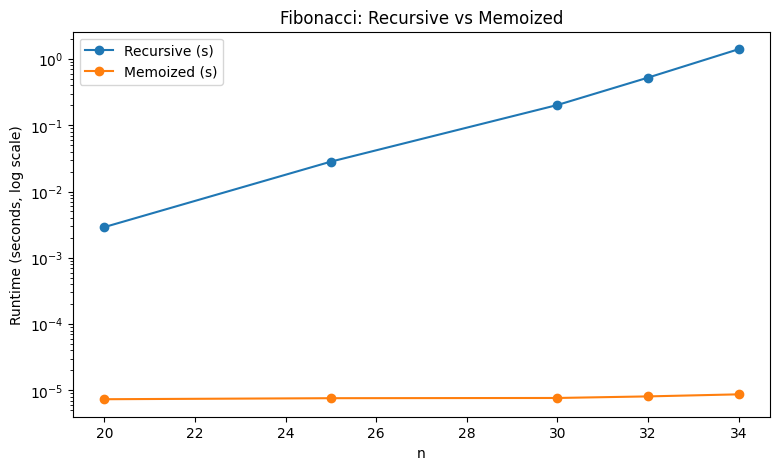

In [9]:

ax = fib_memo_df.set_index("n").plot(marker="o", figsize=(9, 5))
ax.set_yscale("log")
ax.set_title("Fibonacci: Recursive vs Memoized")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_xlabel("n")
plt.show()



# 2. Grid Traveler

## Problem

Imagine an `m × n` grid.

Start in the top-left corner and move only:

- right
- down

How many ways can you reach the bottom-right?

Define:

```text
gridTraveler(m, n)
```

as the number of possible paths through the grid.



## Recursive graph

Suppose we have:

```text
gridTraveler(3, 3)
```

From the current state, there are two possible moves:

```text
                      (3, 3)
                    /        \
                 DOWN        RIGHT
                  /            \
              (2, 3)          (3, 2)
              /   \            /   \
          (1,3)  (2,2)     (2,2)  (3,1)
                   ^          ^
                   |__________|
                 repeated state
```

The recursive relationship is therefore:

$$
grid(m,n)=grid(m-1,n)+grid(m,n-1)
$$

Base cases:

```text
(1, 1) -> 1 way
(0, n) -> 0 ways
(m, 0) -> 0 ways
```


## Brute-force recursion

In [10]:

def grid_traveler_recursive(m, n):
    if m == 1 and n == 1:
        return 1

    if m == 0 or n == 0:
        return 0

    return (
        grid_traveler_recursive(m - 1, n)
        + grid_traveler_recursive(m, n - 1)
    )


print("2 x 3 =", grid_traveler_recursive(2, 3))
print("3 x 3 =", grid_traveler_recursive(3, 3))


2 x 3 = 3
3 x 3 = 6



Again, the recursion works.

But the tree contains repeated states such as:

```text
gridTraveler(2, 2)
```

A larger grid repeats many more states.



## Add memoization

What uniquely identifies a Grid Traveler subproblem?

Two values:

```text
m and n
```

So the memo key can be:

```python
(m, n)
```

and:

```text
memo[(m, n)] = number of paths
```


In [11]:

def grid_traveler_memo(m, n, memo=None):
    if memo is None:
        memo = {}

    key = (m, n)

    if key in memo:
        return memo[key]

    if m == 1 and n == 1:
        return 1

    if m == 0 or n == 0:
        return 0

    memo[key] = (
        grid_traveler_memo(m - 1, n, memo)
        + grid_traveler_memo(m, n - 1, memo)
    )

    return memo[key]


print("18 x 18 =", grid_traveler_memo(18, 18))


18 x 18 = 2333606220



### Complexity intuition

There are only roughly:

```text
m × n
```

unique grid states.

So memoization prevents the enormous recursive tree from repeatedly recalculating the same `(m, n)` combinations.


## Grid Traveler performance comparison

In [17]:

grid_memo_results = []

for size in [5, 7, 9, 10, 11, 13, 14]:
    recursive_result, recursive_time = benchmark(
        grid_traveler_recursive, size, size
    )

    memo_result, memo_time = benchmark(
        grid_traveler_memo, size, size, repeats=100
    )

    assert recursive_result == memo_result

    grid_memo_results.append({
        "Grid": f"{size} x {size}",
        "Recursive (s)": recursive_time,
        "Memoized (s)": memo_time,
    })

grid_memo_df = pd.DataFrame(grid_memo_results)
grid_memo_df


,Grid,Recursive (s),Memoized (s)
0,5 x 5,0.000072,0.000023
1,7 x 7,0.000933,0.000043
2,9 x 9,0.010643,0.000036
3,10 x 10,0.043541,0.000051
4,11 x 11,0.111663,0.000098
5,13 x 13,1.842472,0.000079
6,14 x 14,6.984157,0.000113


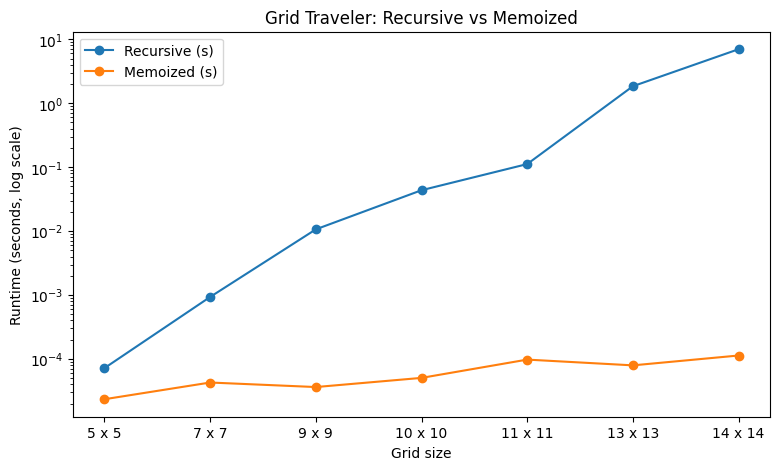

In [18]:

ax = grid_memo_df.set_index("Grid").plot(marker="o", figsize=(9, 5))
ax.set_yscale("log")
ax.set_title("Grid Traveler: Recursive vs Memoized")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_xlabel("Grid size")
plt.show()



# 3. canSum

## Problem

Given:

```text
targetSum
numbers
```

determine whether the target can be created using numbers from the array.

Numbers may be reused.

Example:

```python
canSum(7, [5, 3, 4, 7])
```

returns:

```text
True
```

because:

```text
7
```

or:

```text
3 + 4
```

constructs the target.



## Recursive decision graph

Consider:

```python
canSum(7, [2, 3])
```

At each state, try subtracting each available number:

```text
                              7
                           /     \
                        -2         -3
                        /           \
                       5             4
                     /   \         /   \
                   -2    -3      -2    -3
                   /      \      /      \
                  3        2    2        1
                 ...
```

Each node represents:

```text
the remaining target
```

Eventually:

```text
target == 0
```

means we successfully constructed the original target.

A negative target means that branch overshot.


## Brute-force recursion

In [19]:

def can_sum_recursive(target, numbers):
    if target == 0:
        return True

    if target < 0:
        return False

    for number in numbers:
        remainder = target - number

        if can_sum_recursive(remainder, numbers):
            return True

    return False


print("canSum(7, [5, 3, 4, 7]) =", can_sum_recursive(7, [5, 3, 4, 7]))
print("canSum(7, [2, 4]) =", can_sum_recursive(7, [2, 4]))


canSum(7, [5, 3, 4, 7]) = True
canSum(7, [2, 4]) = False



The recursive solution is correct, but many branches reach the same remaining target.

For example, different sequences of choices may both eventually ask:

```text
canSum(6, numbers)
```

If we already know that answer, we should not solve it again.



## Add memoization

What identifies the subproblem?

The changing value is:

```text
target
```

The `numbers` array stays the same.

So:

```text
memo[target] = whether target can be constructed
```

We should cache both:

```text
True
```

and:

```text
False
```

results.


In [20]:

def can_sum_memo(target, numbers, memo=None):
    if memo is None:
        memo = {}

    if target in memo:
        return memo[target]

    if target == 0:
        return True

    if target < 0:
        return False

    for number in numbers:
        remainder = target - number

        if can_sum_memo(remainder, numbers, memo):
            memo[target] = True
            return True

    memo[target] = False
    return False


print("canSum(300, [7, 14]) =", can_sum_memo(300, [7, 14]))


canSum(300, [7, 14]) = False


## canSum performance comparison

In [30]:

can_sum_memo_results = []

# Impossible targets force brute force to explore many branches.
for target in [50, 152, 174, 222, 253]:
    recursive_result, recursive_time = benchmark(
        can_sum_recursive, target, [7, 14]
    )

    memo_result, memo_time = benchmark(
        can_sum_memo, target, [7, 14], repeats=100
    )

    assert recursive_result == memo_result

    can_sum_memo_results.append({
        "Target": target,
        "Recursive (s)": recursive_time,
        "Memoized (s)": memo_time,
    })

can_sum_memo_df = pd.DataFrame(can_sum_memo_results)
can_sum_memo_df


,Target,Recursive (s),Memoized (s)
0,50,0.000032,0.000008
1,152,0.019704,0.000008
2,174,0.065148,0.000010
3,222,1.798157,0.000011
4,253,18.874814,0.000014


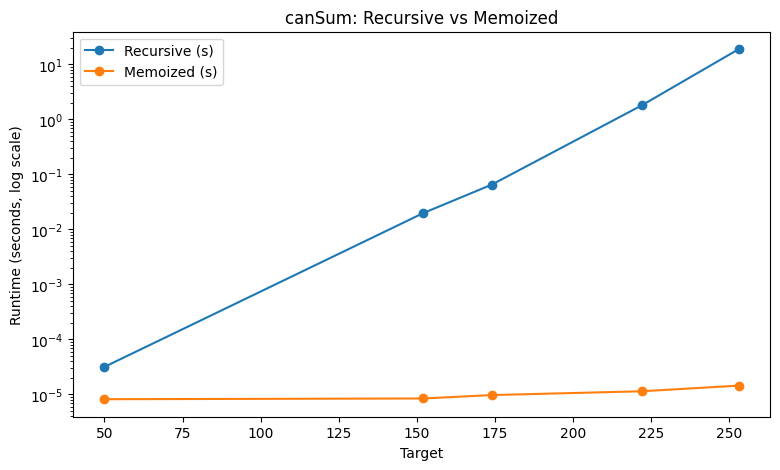

In [31]:

ax = can_sum_memo_df.set_index("Target").plot(marker="o", figsize=(9, 5))
ax.set_yscale("log")
ax.set_title("canSum: Recursive vs Memoized")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_xlabel("Target")
plt.show()



# Memoization Recipe — Main Takeaway

This is the important recipe to remember.

## 1. Make it work

Start with the brute-force recursive solution.

### Visualize the problem as a tree

Ask:

```text
What choices can I make from the current state?
```

Each child represents a smaller version of the same problem.

### Implement the recursive structure

Do not optimize yet.

Focus on:

- recursive calls
- base cases
- correct return values

---

## 2. Make it efficient

Look at the recursion tree.

Ask:

```text
Are any nodes / states repeated?
```

If yes, memoization can help.

### Add a memo object

Usually:

```python
memo = {}
```

### Decide what the memo key should be

The key represents the **changing state** of the subproblem.

Examples:

```text
Fibonacci:
memo[n]

Grid Traveler:
memo[(m, n)]

canSum:
memo[target]
```

### Check the memo first

```python
if state in memo:
    return memo[state]
```

### Store the result before returning

```python
memo[state] = result
return memo[state]
```

---

## Memoization in one sentence

> **Start with recursion, identify repeated subproblems, and cache their answers.**



# Part 2 — Tabulation

Now we change the direction of our thinking.

Memoization was:

```text
large problem
    ↓
smaller problem
    ↓
smaller problem
    ↓
base case
```

Tabulation instead starts from the smallest known answer:

```text
base case
    ↓
larger states
    ↓
larger states
    ↓
target
```

So instead of recursively **pulling answers from smaller states**, we often iteratively **push information into future states**.



# Tabulation Recipe — Main Takeaway

## 1. Visualize the problem as a table

Ask:

```text
What does each position in my table represent?
```

Examples:

```text
Fibonacci:
table[i] = ith Fibonacci number

Grid Traveler:
table[r][c] = number of ways to reach cell (r, c)

canSum:
table[i] = whether sum i is reachable
```

---

## 2. Size the table based on the inputs

Examples:

```text
fib(n)
→ n + 1 entries

canSum(target)
→ target + 1 entries

gridTraveler(m, n)
→ (m + 1) × (n + 1)
```

---

## 3. Initialize the table with default values

Usually:

```text
0
False
empty values
```

depending on what the state represents.

---

## 4. Seed the trivial answer

Ask:

> What state do I already know without doing any work?

Examples:

```text
fib:
table[1] = 1

Grid Traveler:
table[1][1] = 1

canSum:
table[0] = True
```

---

## 5. Iterate through the table

Visit each state in an order where already-known information can be used.

---

## 6. Push the current value into future positions

Ask:

> If this state is reachable / known, where can I go next?

---

## 7. Return the target state

The final table position should represent the original problem.

---

## Tabulation in one sentence

> **Start from a known base state and iteratively propagate information until the target state is solved.**



# 4. Fibonacci — Tabulation

Previously, memoization recursively asked:

```text
fib(n)
→ fib(n - 1)
→ fib(n - 2)
```

For tabulation, start with what is already known:

```text
fib(0) = 0
fib(1) = 1
```

Then build upward.



## Table visualization

For `fib(6)`:

```text
index:  0  1  2  3  4  5  6
table: [0, 1, 0, 0, 0, 0, 0]
```

Using the recurrence:

```text
table[i] = table[i - 1] + table[i - 2]
```

we progressively obtain:

```text
[0, 1, 1, 2, 3, 5, 8]
```


In [32]:

def fib_tabulation(n):
    if n <= 1:
        return n

    table = [0] * (n + 1)
    table[1] = 1

    for i in range(2, n + 1):
        table[i] = table[i - 1] + table[i - 2]

    return table[n]


print("fib_tabulation(40) =", fib_tabulation(40))


fib_tabulation(40) = 102334155



# 5. Grid Traveler — Tabulation

For tabulation:

```text
table[row][col]
```

represents:

> Number of ways to reach that cell.

Seed:

```text
table[1][1] = 1
```

From any cell, every path reaching that cell can continue:

```text
RIGHT
DOWN
```



## Table propagation

Conceptually:

```text
current cell
     |
     +-----> right
     |
     v
    down
```

If:

```python
current = table[row][col]
```

then:

```python
table[row][col + 1] += current
table[row + 1][col] += current
```

when those positions exist.


In [33]:

def grid_traveler_tabulation(m, n):
    if m == 0 or n == 0:
        return 0

    table = [[0] * (n + 1) for _ in range(m + 1)]

    table[1][1] = 1

    for row in range(m + 1):
        for col in range(n + 1):
            current = table[row][col]

            if col + 1 <= n:
                table[row][col + 1] += current

            if row + 1 <= m:
                table[row + 1][col] += current

    return table[m][n]


print("18 x 18 =", grid_traveler_tabulation(18, 18))


18 x 18 = 2333606220



# 6. canSum — Tabulation

This is where the course begins applying the tabulation recipe to decision problems.

Define:

```text
table[i] = whether sum i can be constructed
```

For a target of `7`:

```text
index:   0      1      2      3      4      5      6      7
table:  False  False  False  False  False  False  False  False
```

The trivial state is:

```text
sum 0 is always possible
```

because choosing no numbers creates zero.

So:

```text
table[0] = True
```



## Propagation example

For:

```python
canSum(7, [5, 3, 4])
```

start with:

```text
index:   0      1      2      3      4      5      6      7
table:  True   False  False  False  False  False  False  False
```

Since index `0` is reachable:

```text
0 + 5 = 5
0 + 3 = 3
0 + 4 = 4
```

so:

```text
table[5] = True
table[3] = True
table[4] = True
```

When we later reach `3`:

```text
3 + 3 = 6
3 + 4 = 7
```

so `7` becomes reachable.

The target state is therefore `True`.


In [34]:

def can_sum_tabulation(target, numbers):
    table = [False] * (target + 1)

    table[0] = True

    for i in range(target + 1):

        if table[i]:

            for number in numbers:
                next_sum = i + number

                if next_sum <= target:
                    table[next_sum] = True

    return table[target]


print("canSum(7, [5, 3, 4, 7]) =", can_sum_tabulation(7, [5, 3, 4, 7]))
print("canSum(300, [7, 14]) =", can_sum_tabulation(300, [7, 14]))


canSum(7, [5, 3, 4, 7]) = True
canSum(300, [7, 14]) = False



# Final comparison: Recursion vs Memoization vs Tabulation

Now that both approaches have been learned separately, we can compare them directly.

The exact times depend on the computer running the notebook.

The important observation is the **growth pattern**, not any single timing measurement.


In [35]:

comparison_rows = []

# Fibonacci
n = 34
_, recursive_time = benchmark(fib_recursive, n)
_, memo_time = benchmark(fib_memo, n, repeats=100)
_, tab_time = benchmark(fib_tabulation, n, repeats=100)

comparison_rows.append({
    "Problem": f"fib({n})",
    "Recursive": format_time(recursive_time),
    "Memoized": format_time(memo_time),
    "Tabulated": format_time(tab_time),
})

# Grid Traveler
size = 11
_, recursive_time = benchmark(grid_traveler_recursive, size, size)
_, memo_time = benchmark(grid_traveler_memo, size, size, repeats=100)
_, tab_time = benchmark(grid_traveler_tabulation, size, size, repeats=100)

comparison_rows.append({
    "Problem": f"gridTraveler({size}, {size})",
    "Recursive": format_time(recursive_time),
    "Memoized": format_time(memo_time),
    "Tabulated": format_time(tab_time),
})

# canSum
target = 50
_, recursive_time = benchmark(can_sum_recursive, target, [7, 14])
_, memo_time = benchmark(can_sum_memo, target, [7, 14], repeats=100)
_, tab_time = benchmark(can_sum_tabulation, target, [7, 14], repeats=100)

comparison_rows.append({
    "Problem": f"canSum({target}, [7, 14])",
    "Recursive": format_time(recursive_time),
    "Memoized": format_time(memo_time),
    "Tabulated": format_time(tab_time),
})

pd.DataFrame(comparison_rows)


,Problem,Recursive,Memoized,Tabulated
0,fib(34),1.4650 s,8.6840 µs,6.5620 µs
1,"gridTraveler(11, 11)",118.1154 ms,59.0670 µs,54.5840 µs
2,"canSum(50, [7, 14])",28.1000 µs,6.3750 µs,3.2760 µs



# Large inputs

For sufficiently large inputs, brute-force recursion can become unreasonable to run.

Dynamic programming does more than make the program *a little faster*.

It can turn a problem from practically unusable into something that finishes almost immediately.


In [36]:

large_tests = []

fib_value, fib_memo_time = benchmark(fib_memo, 500)
_, fib_tab_time = benchmark(fib_tabulation, 500)

large_tests.append({
    "Problem": "fib(500)",
    "Memoized": format_time(fib_memo_time),
    "Tabulated": format_time(fib_tab_time),
    "Brute force": "Not run — exponential growth",
})

grid_value, grid_memo_time = benchmark(grid_traveler_memo, 30, 30)
_, grid_tab_time = benchmark(grid_traveler_tabulation, 30, 30)

large_tests.append({
    "Problem": "gridTraveler(30, 30)",
    "Memoized": format_time(grid_memo_time),
    "Tabulated": format_time(grid_tab_time),
    "Brute force": "Not run — enormous recursion tree",
})

can_value, can_memo_time = benchmark(can_sum_memo, 1000, [7, 14])
_, can_tab_time = benchmark(can_sum_tabulation, 1000, [7, 14])

large_tests.append({
    "Problem": "canSum(1000, [7, 14])",
    "Memoized": format_time(can_memo_time),
    "Tabulated": format_time(can_tab_time),
    "Brute force": "Not run — potentially enormous search",
})

pd.DataFrame(large_tests)


,Problem,Memoized,Tabulated,Brute force
0,fib(500),476.0000 µs,115.5999 µs,Not run — exponential growth
1,"gridTraveler(30, 30)",949.4000 µs,471.2001 µs,Not run — enormous recursion tree
2,"canSum(1000, [7, 14])",155.9000 µs,115.2999 µs,Not run — potentially enormous search



# Final mental model

## Memoization

```text
                         Original problem
                                |
                                v
                         Build recursion tree
                                |
                                v
                        Make brute force work
                                |
                                v
                     Find repeated subproblems
                                |
                                v
                           Cache results
                                |
                                v
                          MEMOIZATION
```

Think:

> **Solve downward recursively and remember answers.**

---

## Tabulation

```text
                          Define table state
                                |
                                v
                         Size the table
                                |
                                v
                       Seed a known base case
                                |
                                v
                    Iterate through known states
                                |
                                v
                    Push into future positions
                                |
                                v
                           TABULATION
```

Think:

> **Start from what you know and build upward.**

---

# Most important interview habit

Before writing DP code, define your state in English:

```text
dp[i] = ___________________________________
```

Examples:

```text
dp[i] = ith Fibonacci number

dp[i] = whether sum i is reachable

dp[i] = whether the first i characters of a string can be segmented
```

If that sentence is clear, the implementation becomes much easier.


# Let's work on the next few problems:
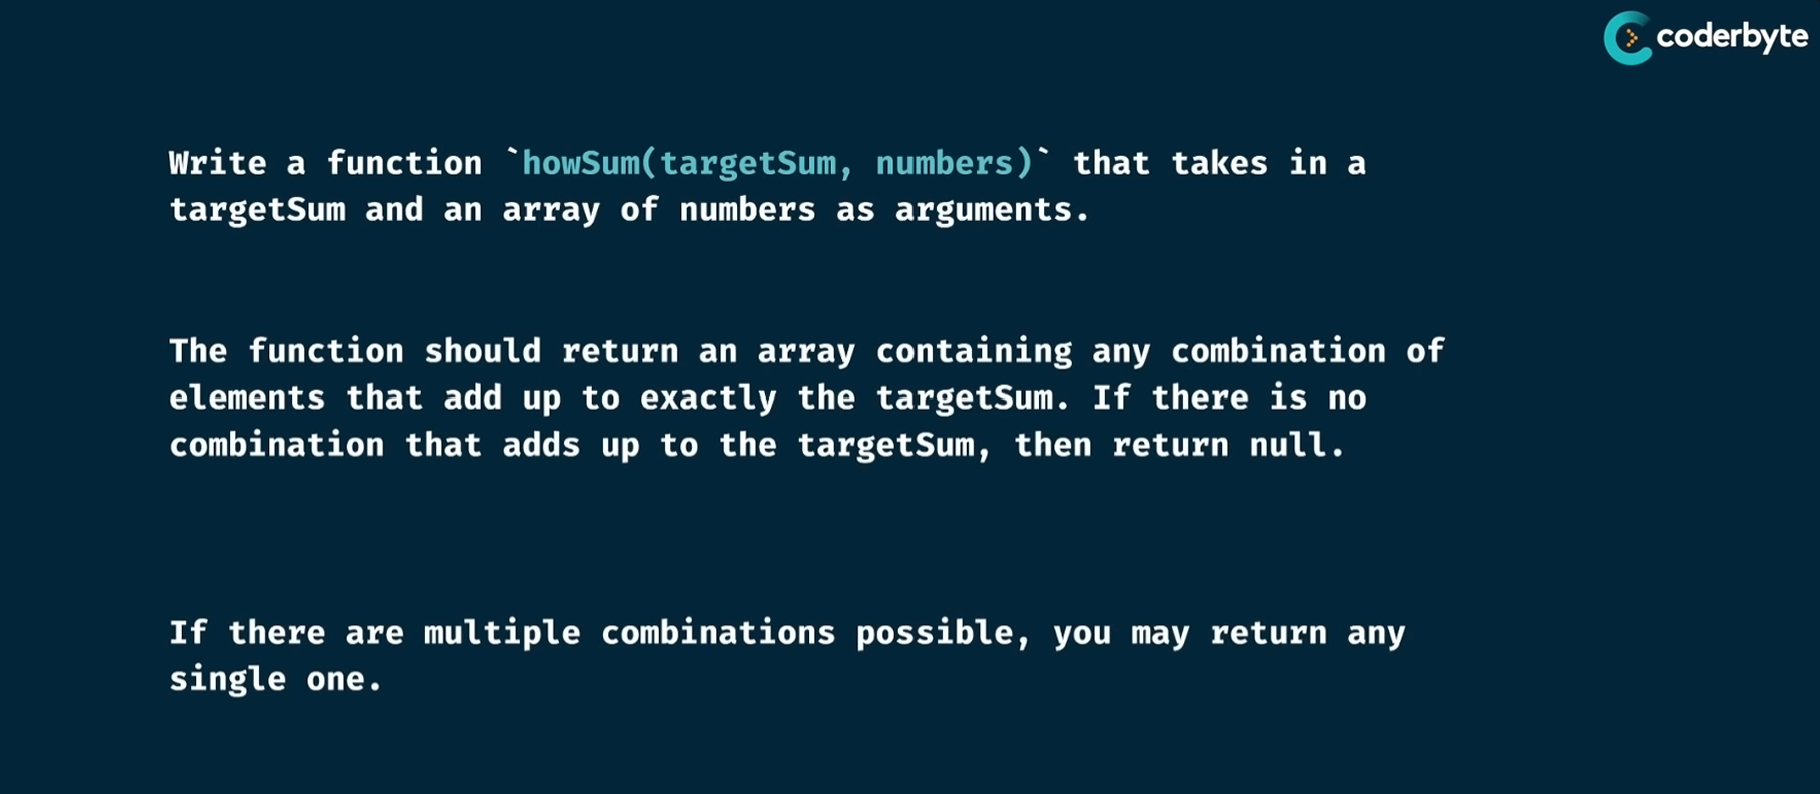
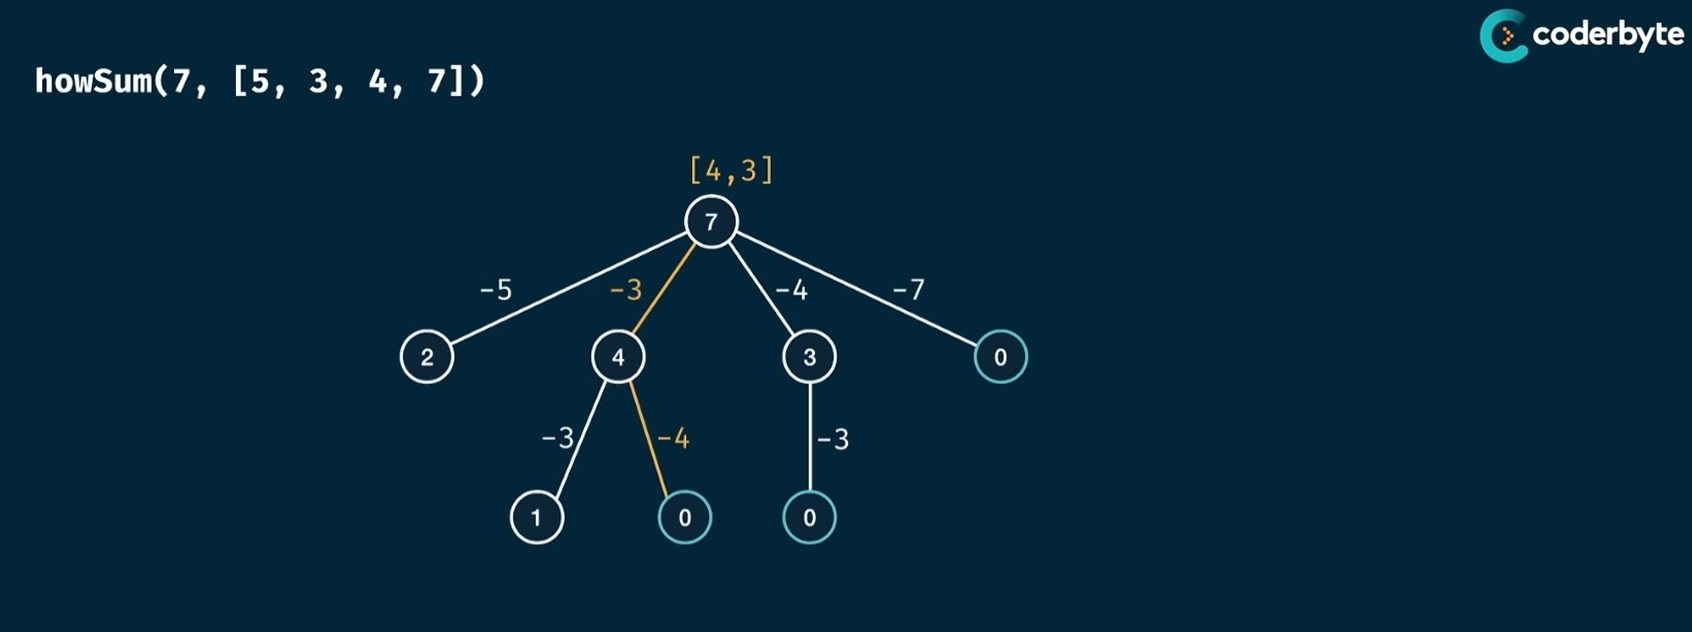

In [57]:
# Brute-Force Recursion
def how_sum_recursive(target_sum, numbers):
    if target_sum == 0: return []
    if target_sum < 0: return None

    for num in numbers:
        remainder = target_sum - num
        remainder_res = how_sum_recursive(remainder, numbers)

        if remainder_res is not None:
            return remainder_res + [num]

    return None

print("how_sum_recursive")
print(how_sum_recursive(7, [2, 3])) # [3, 2, 2]
print(how_sum_recursive(7, [5, 3, 4, 7])) # [4, 3]
print(how_sum_recursive(7, [2, 4])) # None
print(how_sum_recursive(8, [2, 3, 5])) # [2, 2, 2, 2]
# print(how_sum_recursive(300, [7, 14])) # None -> Brute force will hang on this one

# m = targetSum
# n = len(numbers)

# time: O(n^m * m)
# space: O(n)

# Memoization
# Add memo object to function and recursive calls
# Add base case to return memo values
# Store return values into memo

# Memoization Recursion
def how_sum_memo(target_sum, numbers, memo=None):
    if memo is None: memo = {}
    if target_sum in memo: return memo[target_sum]
    if target_sum == 0: return []
    if target_sum < 0: return None

    for num in numbers:
        remainder = target_sum - num
        remainder_res = how_sum_memo(remainder, numbers, memo)

        if remainder_res is not None:
            memo[target_sum] = remainder_res + [num]
            return memo[target_sum]

    memo[target_sum] = None
    return None

print("\nhow_sum_memo")
print(how_sum_memo(7, [2, 3])) # [3, 2, 2]
print(how_sum_memo(7, [5, 3, 4, 7])) # [4, 3]
print(how_sum_memo(7, [2, 4])) # None
print(how_sum_memo(8, [2, 3, 5])) # [2, 2, 2, 2]
print(how_sum_memo(300, [7, 14])) # None

# m = target_sum
# n = len(numbers)

# Time:  O(n * m^2)
# Space: O(m^2)

"""
how_sum_tabulation(7, [5, 3, 4]) -> [4, 3]

Initial:
    0       1       2       3       4       5       6       7
[   []     None    None    None    None    None    None    None   ]

At i = 0:
dp[0] = []

Try each number:
0 + 5 = 5  -> dp[5] = [] + [5] = [5]
0 + 3 = 3  -> dp[3] = [] + [3] = [3]
0 + 4 = 4  -> dp[4] = [] + [4] = [4]

Result:
    0       1       2       3       4       5       6       7
[   []     None    None    [3]     [4]     [5]    None    None   ]

At i = 1:

dp[1] = None

    0       1       2       3       4       5       6       7
[   []     None    None    [3]     [4]     [5]    None    None   ]

Same i = 2:

    0       1       2       3       4       5       6       7
[   []     None    None    [3]     [4]     [5]    None    None   ]

At i = 3:

Updated table:

    0       1       2       3       4       5        6        7
[   []     None    None    [3]     [4]     [5]    [3,3]    [3,4]   ]

...
"""

# Tabulation Dynamic Programming
def how_sum_tabulation(target_sum, numbers):
    dp = [None] * (target_sum + 1)
    dp[0] = []

    for i in range(target_sum):
        if dp[i] is not None:
            for num in numbers:
                if i + num <= target_sum:
                    dp[i + num] = dp[i] + [num]

    return dp[target_sum]


print("\nhow_sum_tabulation")
print(how_sum_tabulation(7, [2, 3])) # [3, 2, 2]
print(how_sum_tabulation(7, [5, 3, 4, 7])) # [4, 3]
print(how_sum_tabulation(7, [2, 4])) # None
print(how_sum_tabulation(8, [2, 3, 5])) # [2, 2, 2, 2]
print(how_sum_tabulation(300, [7, 14])) # None

# m = target_sum
# n = len(numbers)
#
# Time:  O(n * m^2)
# Space: O(m^2)



how_sum_recursive
[3, 2, 2]
[4, 3]
None
[2, 2, 2, 2]

how_sum_memo
[3, 2, 2]
[4, 3]
None
[2, 2, 2, 2]
None

how_sum_tabulation
[3, 2, 2]
[4, 3]
None
[2, 2, 2, 2]
None


In [58]:
# Brute-Force Recursion

def best_sum_recursive(target_sum, numbers):
    if target_sum == 0:
        return []

    if target_sum < 0:
        return None

    shortest_combination = None

    for num in numbers:
        remainder = target_sum - num

        remainder_res = best_sum_recursive(remainder, numbers)

        if remainder_res is not None:
            combination = remainder_res + [num]

            # If this is the first valid combination
            # OR it is shorter than our current shortest,
            # save it.
            if (
                shortest_combination is None
                or len(combination) < len(shortest_combination)
            ):
                shortest_combination = combination

    return shortest_combination


print("best_sum_recursive")

print(best_sum_recursive(7, [5, 3, 4, 7]))   # [7]
print(best_sum_recursive(8, [2, 3, 5]))      # [5, 3]
print(best_sum_recursive(8, [1, 4, 5]))      # [4, 4]

# print(best_sum_recursive(100, [1, 2, 5, 25]))
# Brute force becomes extremely slow


# m = target_sum
# n = len(numbers)
#
# Time:  O(n^m * m)
# Space: O(m^2)

# Memoization
#
# Add memo object to function and recursive calls
# Add base case to return memo values
# Store return values into memo

def best_sum_memo(target_sum, numbers, memo=None):
    if memo is None:
        memo = {}

    if target_sum in memo:
        return memo[target_sum]

    if target_sum == 0:
        return []

    if target_sum < 0:
        return None

    shortest_combination = None

    for num in numbers:
        remainder = target_sum - num

        remainder_res = best_sum_memo(
            remainder,
            numbers,
            memo
        )

        if remainder_res is not None:
            combination = remainder_res + [num]

            if (
                shortest_combination is None
                or len(combination) < len(shortest_combination)
            ):
                shortest_combination = combination

    memo[target_sum] = shortest_combination

    return shortest_combination


print("\nbest_sum_memo")

print(best_sum_memo(7, [5, 3, 4, 7]))      # [7]
print(best_sum_memo(8, [2, 3, 5]))         # [5, 3]
print(best_sum_memo(8, [1, 4, 5]))         # [4, 4]
print(best_sum_memo(100, [1, 2, 5, 25]))   # [25, 25, 25, 25]


# m = target_sum
# n = len(numbers)
#
# Time:  O(n * m^2)
# Space: O(m^2)
"""
best_sum_tabulation(8, [2, 3, 5]) -> [3, 5]

Initial:

    0       1       2       3       4       5       6       7       8

[   []     None    None    None    None    None    None    None    None   ]

dp[0] = []

Try every number:

0 + 2 = 2
dp[2] = [] + [2]
      = [2]

0 + 3 = 3
dp[3] = [] + [3]
      = [3]

0 + 5 = 5
dp[5] = [] + [5]
      = [5]


Result:

    0       1       2       3       4       5       6       7       8

[   []     None    [2]     [3]    None     [5]    None    None    None   ]

dp[1] = None

    0       1       2       3       4       5       6       7       8

[   []     None    [2]     [3]    None     [5]    None    None    None   ]

dp[2] = [2]

    0       1       2       3       4        5       6        7       8

[   []     None    [2]     [3]    [2,2]     [5]    None    [2,5]    None   ]
"""

def best_sum_tabulation(target_sum, numbers):
    dp = [None] * (target_sum + 1)

    dp[0] = []

    for i in range(target_sum):
        if dp[i] is not None:

            for num in numbers:
                next_sum = i + num

                if next_sum <= target_sum:
                    combination = dp[i] + [num]

                    # Only store this combination if:
                    #
                    # 1. We have never reached next_sum before
                    # OR
                    # 2. This combination is shorter than
                    #    the one currently stored
                    if (
                        dp[next_sum] is None
                        or len(combination) < len(dp[next_sum])
                    ):
                        dp[next_sum] = combination

    return dp[target_sum]


print("\nbest_sum_tabulation")

print(best_sum_tabulation(7, [5, 3, 4, 7]))      # [7]
print(best_sum_tabulation(8, [2, 3, 5]))         # [3, 5]
print(best_sum_tabulation(8, [1, 4, 5]))         # [4, 4]
print(best_sum_tabulation(100, [1, 2, 5, 25]))   # [25, 25, 25, 25]


# m = target_sum
# n = len(numbers)
#
# Time:  O(n * m^2)
# Space: O(m^2)

best_sum_recursive
[7]
[5, 3]
[4, 4]

best_sum_memo
[7]
[5, 3]
[4, 4]
[25, 25, 25, 25]

best_sum_tabulation
[7]
[3, 5]
[4, 4]
[25, 25, 25, 25]


In [60]:
"""
allConstruct:
explore EVERY successful branch (leetcode word break basically)

                          "purple"

                /                           \
            "purp"                          "p"
              |                              |
             "le"                           "urple"
              |                              |
             "le"                           "ur"
              |                              |
              ""                            "ple"
        ["purp", "le"]                        |
                                             "p"
                                              |
                                             "le"
                                              |
                                              ""
                                    ["p", "ur", "p", "le"]

res = [
    ["purp", "le"],
    ["p", "ur", "p", "le"]
]
"""

# Brute-Force Recursion

def all_construct_recursive(target, word_bank):
    if target == "":
        return [[]]

    result = []

    for word in word_bank:

        # Only use the word if it matches the beginning
        # of the current target.
        if target.startswith(word):
            suffix = target[len(word):]

            suffix_ways = all_construct_recursive(
                suffix,
                word_bank
            )

            # Add the current word to every way
            # of constructing the remaining suffix.
            target_ways = [
                [word] + way
                for way in suffix_ways
            ]

            result.extend(target_ways)

    return result


print("all_construct_recursive")

print(
    all_construct_recursive(
        "purple",
        ["purp", "p", "ur", "le", "purpl"]
    )
)
# [
#   ["purp", "le"],
#   ["p", "ur", "p", "le"]
# ]

print(
    all_construct_recursive(
        "abcdef",
        ["ab", "abc", "cd", "def", "abcd", "ef", "c"]
    )
)

print(
    all_construct_recursive(
        "skateboard",
        ["bo", "rd", "ate", "t", "ska", "sk", "boar"]
    )
)
# []


# DON'T run a huge impossible brute-force case:
#
# print(
#     all_construct_recursive(
#         "eeeeeeeeeeeeeeeeeeeeeeeeeeeeef",
#         ["e", "ee", "eee", "eeee", "eeeee"]
#     )
# )


# m = len(target)
# n = len(word_bank)
#
# Time:  exponential
#        roughly O(n^m * m) when accounting for
#        constructing/copying returned combinations
#
# Space: can also be exponential because ALL
#        valid constructions must be returned

# Memoization
#
# Add memo object to function and recursive calls
# Add base case to return memo values
# Store return values into memo

def all_construct_memo(target, word_bank, memo=None):
    if memo is None:
        memo = {}

    if target in memo:
        return memo[target]

    if target == "":
        return [[]]

    result = []

    for word in word_bank:

        if target.startswith(word):
            suffix = target[len(word):]

            suffix_ways = all_construct_memo(
                suffix,
                word_bank,
                memo
            )

            target_ways = [
                [word] + way
                for way in suffix_ways
            ]

            result.extend(target_ways)

    memo[target] = result

    return result


print("\nall_construct_memo")

print(
    all_construct_memo(
        "purple",
        ["purp", "p", "ur", "le", "purpl"]
    )
)

print(
    all_construct_memo(
        "abcdef",
        ["ab", "abc", "cd", "def", "abcd", "ef", "c"]
    )
)

print(
    all_construct_memo(
        "skateboard",
        ["bo", "rd", "ate", "t", "ska", "sk", "boar"]
    )
)


# m = len(target)
# n = len(word_bank)
#
# Worst-case Time: exponential
# Worst-case Space: exponential
#
# Unlike canConstruct, memoization cannot make
# allConstruct polynomial in the worst case because
# the number of valid constructions itself may
# be exponential.

"""
initial:

      0       1       2       3       4       5       6

[   [[]]     []      []      []      []      []      []   ]

iteration 1:

       0          1       2     3        4           5        6

[    [[]]      [["p"]]    []    []   [["purp"]]  [["purpl"]]  []   ]

iteration 2:

       0          1       2         3             4           5        6

[    [[]]      [["p"]]    []   [["p","ur"]]   [["purp"]]  [["purpl"]]  []   ]

...
"""

def all_construct_tabulation(target, word_bank):
    dp = [[] for _ in range(len(target) + 1)]

    # One way to construct the empty string:
    # use no words.
    dp[0] = [[]]

    for i in range(len(target) + 1):

        for word in word_bank:

            # Does this word match the target starting at i?
            if target[i:i + len(word)] == word:
                next_index = i + len(word)

                if next_index <= len(target):

                    # Add this word to every construction
                    # that already reaches index i.
                    new_combinations = [
                        combination + [word]
                        for combination in dp[i]
                    ]

                    # allConstruct keeps ALL possible
                    # constructions, so extend rather
                    # than overwrite.
                    dp[next_index].extend(
                        new_combinations
                    )

    return dp[len(target)]


print("\nall_construct_tabulation")

print(
    all_construct_tabulation(
        "purple",
        ["purp", "p", "ur", "le", "purpl"]
    )
)
# [
#   ["purp", "le"],
#   ["p", "ur", "p", "le"]
# ]


print(
    all_construct_tabulation(
        "abcdef",
        ["ab", "abc", "cd", "def", "abcd", "ef", "c"]
    )
)


print(
    all_construct_tabulation(
        "skateboard",
        ["bo", "rd", "ate", "t", "ska", "sk", "boar"]
    )
)
# []


# m = len(target)
# n = len(word_bank)
#
# Worst-case Time: exponential
# Worst-case Space: exponential
#
# More explicitly, if there are exponentially many
# constructions, we must create and store all of them.

all_construct_recursive
[['purp', 'le'], ['p', 'ur', 'p', 'le']]
[['ab', 'cd', 'ef'], ['ab', 'c', 'def'], ['abc', 'def'], ['abcd', 'ef']]
[]

all_construct_memo
[['purp', 'le'], ['p', 'ur', 'p', 'le']]
[['ab', 'cd', 'ef'], ['ab', 'c', 'def'], ['abc', 'def'], ['abcd', 'ef']]
[]

all_construct_tabulation
[['purp', 'le'], ['p', 'ur', 'p', 'le']]
[['abc', 'def'], ['ab', 'c', 'def'], ['abcd', 'ef'], ['ab', 'cd', 'ef']]
[]
